In [2]:
# ============================================================================
# FOIL - First Order Inductive Learner
# BCI702 : Machine Learning : Module 2 : Learning Sets of Rules
# Single-cell Google Colab demonstration with full visual analysis
# ============================================================================

!pip install -q networkx matplotlib seaborn pandas tabulate

In [3]:
import math
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

In [4]:
# ============================================================================
# SECTION 1 : THE KNOWLEDGE BASE (background predicates)
# ============================================================================
# Family:
#      Tom  +  Mary   ->  Bob  and  Dave
#      Bob            ->  Sharon and Victor
#      Dave           ->  Ann
#
# Closed World Assumption: anything NOT listed below is FALSE.
# ============================================================================

CONSTANTS = [
    "Tom",
    "Mary",
    "Bob",
    "Dave",
    "Sharon",
    "Victor",
    "Ann"
]

FACTS = {
    "Father": {
        ("Tom", "Bob"),
        ("Tom", "Dave"),
        ("Bob", "Sharon"),
        ("Bob", "Victor"),
        ("Dave", "Ann")
    },

    "Mother": {
        ("Mary", "Bob"),
        ("Mary", "Dave")
    },

    "Female": {
        ("Mary",),
        ("Sharon",),
        ("Ann",)
    }
}

ARITY = {
    "Father": 2,
    "Mother": 2,
    "Female": 1
}

TARGET = "GrandDaughter"
TARGET_VARS = ("x", "y")


def is_true(pred, args):
    """Closed world lookup."""
    return tuple(args) in FACTS[pred]


def ground_truth(x, y):
    """x is the grand-daughter of y."""

    if not is_true("Female", (x,)):
        return False

    for z in CONSTANTS:

        parent_of_z = (
            is_true("Father", (y, z))
            or is_true("Mother", (y, z))
        )

        parent_of_x = (
            is_true("Father", (z, x))
            or is_true("Mother", (z, x))
        )

        if parent_of_z and parent_of_x:
            return True

    return False

In [5]:
ALL_PAIRS = [
    (a, b)
    for a in CONSTANTS
    for b in CONSTANTS
]

POSITIVES = [
    p
    for p in ALL_PAIRS
    if ground_truth(*p)
]

NEGATIVES = [
    p
    for p in ALL_PAIRS
    if not ground_truth(*p)
]

print("=" * 78)
print(" FOIL : FIRST ORDER INDUCTIVE LEARNER ".center(78, "="))
print("=" * 78)

print(
    "\nConstants (%d) : %s"
    % (len(CONSTANTS), ", ".join(CONSTANTS))
)

print(
    "Total possible %s(x,y) pairs : %d"
    % (TARGET, len(ALL_PAIRS))
)

print(
    "Positive examples : %d  -> %s"
    % (len(POSITIVES), POSITIVES)
)

print(
    "Negative examples : %d"
    % len(NEGATIVES)
)

kb_rows = []

for p in ["Father", "Mother", "Female"]:
    for t in sorted(FACTS[p]):
        kb_rows.append([
            p,
            ", ".join(t)
        ])

print("\nBACKGROUND KNOWLEDGE BASE")

print(
    tabulate(
        kb_rows,
        headers=["Predicate", "Arguments"],
        tablefmt="grid"
    )
)

==================== FOIL : FIRST ORDER INDUCTIVE LEARNER ====================

Constants (7) : Tom, Mary, Bob, Dave, Sharon, Victor, Ann
Total possible GrandDaughter(x,y) pairs : 49
Positive examples : 4  -> [('Sharon', 'Tom'), ('Sharon', 'Mary'), ('Ann', 'Tom'), ('Ann', 'Mary')]
Negative examples : 45

BACKGROUND KNOWLEDGE BASE
+-------------+-------------+
| Predicate   | Arguments   |
+=============+=============+
| Father      | Bob, Sharon |
+-------------+-------------+
| Father      | Bob, Victor |
+-------------+-------------+
| Father      | Dave, Ann   |
+-------------+-------------+
| Father      | Tom, Bob    |
+-------------+-------------+
| Father      | Tom, Dave   |
+-------------+-------------+
| Mother      | Mary, Bob   |
+-------------+-------------+
| Mother      | Mary, Dave  |
+-------------+-------------+
| Female      | Ann         |
+-------------+-------------+
| Female      | Mary        |
+-------------+-------------+
| Female      | Sharon      |
+-------

In [6]:
# ============================================================================
# SECTION 2 : LITERALS, BINDINGS AND RULE EVALUATION
# ============================================================================
# A LITERAL is (negated, predicate, variable_tuple)
# e.g. (False, 'Father', ('y','z'))
#
# A BINDING is a dict mapping variable -> constant
# e.g. {'x':'Sharon','y':'Tom'}
#
# KEY IDEA: FOIL does not count EXAMPLES, it counts BINDINGS.
# Adding a literal with a NEW variable can make one example produce
# several rows in the binding table.
# ============================================================================


def lit_str(lit):
    neg, pred, vs = lit

    return (
        ("not " if neg else "")
        + "%s(%s)" % (pred, ",".join(vs))
    )


def rule_str(body):
    head = "%s(%s)" % (
        TARGET,
        ",".join(TARGET_VARS)
    )

    if not body:
        return head + " :- "

    return head + " :- " + ", ".join(
        lit_str(l)
        for l in body
    )


def extend_bindings(bindings, lit):
    """Apply one literal to a binding table.

    Returns (new_bindings, parents) where parents[i] is the index of the
    OLD binding that produced new_bindings[i]. We need parents to compute t.
    """

    neg, pred, vs = lit

    new_bindings = []
    parents = []

    for i, b in enumerate(bindings):

        if neg:
            # Negated literals never introduce new variables.
            args = tuple(
                b[v]
                for v in vs
            )

            if not is_true(pred, args):
                new_bindings.append(dict(b))
                parents.append(i)

        else:

            for fact in FACTS[pred]:

                nb = dict(b)
                ok = True

                for var, val in zip(vs, fact):

                    if var in nb:

                        if nb[var] != val:
                            ok = False
                            break

                    else:
                        nb[var] = val

                if ok:
                    new_bindings.append(nb)
                    parents.append(i)

    return new_bindings, parents


def evaluate_rule(body, pairs):
    """Which (x,y) pairs does this rule body cover?"""

    bindings = [
        {
            "x": a,
            "y": b
        }
        for (a, b) in pairs
    ]

    for lit in body:
        bindings, _ = extend_bindings(
            bindings,
            lit
        )

    return {
        (b["x"], b["y"])
        for b in bindings
    }


def split_bindings(bindings, pos_set):
    """Return (positive_binding_indices, negative_binding_indices)."""

    pos_idx = [
        i
        for i, b in enumerate(bindings)
        if (b["x"], b["y"]) in pos_set
    ]

    neg_idx = [
        i
        for i, b in enumerate(bindings)
        if (b["x"], b["y"]) not in pos_set
    ]

    return pos_idx, neg_idx

In [7]:
# ============================================================================
# SECTION 3 : CANDIDATE LITERAL GENERATION
# ============================================================================
# Rules of the game:
#   - at least ONE variable must already exist in the rule
#   - at most ONE brand new variable may be introduced per literal
#   - LINKAGE RULE: no second new variable until the first one has been
#     used twice.
#
# Without this, greedy FOIL happily learns junk such as:
# "Father(w,x)" which only means "x has some father somewhere".
#
# Set ENFORCE_LINKAGE = False and re-run to show students the mess.
#
# Negated literals: switch USE_NEGATION on to discuss why the closed
# world assumption makes them almost vacuously true on a tiny KB.
#
# Equality literals are omitted (real FOIL includes Equal(x,y))
# ============================================================================

NEW_VAR_POOL = ["z", "w", "v"]

ENFORCE_LINKAGE = True
USE_NEGATION = False


def has_dangling_variable(body):
    """True if some body-only variable has been used just once so far."""

    counts = {}

    for _, _, vs in body:

        for v in vs:
            counts[v] = counts.get(v, 0) + 1

    return any(
        v not in TARGET_VARS and c < 2
        for v, c in counts.items()
    )


def candidate_literals(body):

    used = set(TARGET_VARS)

    for _, _, vs in body:
        used.update(vs)

    fresh = next(
        v
        for v in NEW_VAR_POOL
        if v not in used
    )

    allow_new = not (
        ENFORCE_LINKAGE
        and has_dangling_variable(body)
    )

    pool = sorted(used) + (
        [fresh]
        if allow_new
        else []
    )

    existing = set(used)

    cands = []

    for pred, k in ARITY.items():

        for combo in itertools.product(
            pool,
            repeat=k
        ):

            if not any(
                v in existing
                for v in combo
            ):
                continue

            # Only one new variable.
            if combo.count(fresh) > 1:
                continue

            for neg in (
                (False, True)
                if USE_NEGATION
                else (False,)
            ):

                # No new vars under negation.
                if neg and fresh in combo:
                    continue

                lit = (
                    neg,
                    pred,
                    combo
                )

                if lit not in body:
                    cands.append(lit)

    return cands


def n_new_vars(lit, body):

    used = set(TARGET_VARS)

    for _, _, vs in body:
        used.update(vs)

    return len([
        v
        for v in set(lit[2])
        if v not in used
    ])

In [8]:
# ============================================================================
# SECTION 4 : FOIL_GAIN
# ============================================================================
#
# Foil_Gain(L,R) =
#
# t * [
#     log2( p1/(p1+n1) )
#     -
#     log2( p0/(p0+n0) )
# ]
#
# p0,n0 = pos/neg BINDINGS of rule R before adding L
# p1,n1 = pos/neg BINDINGS of rule R after adding L
# t     = how many positive bindings of R SURVIVE the addition
# ============================================================================


def foil_gain(p0, n0, p1, n1, t):

    if (
        p1 == 0
        or p0 == 0
        or t == 0
    ):
        return float("-inf")

    return t * (
        math.log2(
            p1 / (p1 + n1)
        )
        -
        math.log2(
            p0 / (p0 + n0)
        )
    )

In [9]:
# ============================================================================
# SECTION 5 : LEARN-ONE-RULE (inner loop) and SEQUENTIAL COVERING (outer)
# ============================================================================

TRACE = []
RULES = []
ROUND_LOG = []


def learn_one_rule(pos, neg, round_no):

    pos_set = set(pos)

    universe = list(pos) + list(neg)

    body = []

    bindings = [
        {
            "x": a,
            "y": b
        }
        for (a, b) in universe
    ]

    pos_idx, neg_idx = split_bindings(
        bindings,
        pos_set
    )

    p0 = len(pos_idx)
    n0 = len(neg_idx)

    step = 0

    while n0 > 0 and step < 6:

        step += 1

        scored = []

        for lit in candidate_literals(body):

            nb, parents = extend_bindings(
                bindings,
                lit
            )

            npos, nneg = split_bindings(
                nb,
                pos_set
            )

            p1 = len(npos)
            n1 = len(nneg)

            surviving_parents = {
                parents[i]
                for i in npos
            }

            t = len(
                surviving_parents
                & set(pos_idx)
            )

            g = foil_gain(
                p0,
                n0,
                p1,
                n1,
                t
            )

            scored.append({
                "round": round_no,
                "step": step,
                "literal": lit_str(lit),
                "p1": p1,
                "n1": n1,
                "t": t,
                "gain": g,
                "newvars": n_new_vars(
                    lit,
                    body
                )
            })

        # Tie-break:
        # highest gain,
        # then fewest new variables,
        # then name.

        scored.sort(
            key=lambda d: (
                -d["gain"],
                d["newvars"],
                d["literal"]
            )
        )

        TRACE.extend(scored)

        best = scored[0]

        if best["gain"] == float("-inf"):
            break

        best_lit = next(
            l
            for l in candidate_literals(body)
            if lit_str(l) == best["literal"]
        )

        print(
            "\n  Step %d : rule before -> %s   (p=%d, n=%d)"
            % (
                step,
                rule_str(body),
                p0,
                n0
            )
        )

        top = pd.DataFrame([
            s
            for s in scored
            if s["gain"] > float("-inf")
        ])[[
            "literal",
            "p1",
            "n1",
            "t",
            "gain"
        ]].head(6)

        top["gain"] = top["gain"].round(3)

        print(
            tabulate(
                top,
                headers=[
                    "candidate literal",
                    "p1",
                    "n1",
                    "t",
                    "FOIL_Gain"
                ],
                tablefmt="simple",
                showindex=False
            )
        )

        print(
            "  --> CHOSEN : %s"
            % best["literal"]
        )

        body.append(best_lit)

        bindings, _ = extend_bindings(
            bindings,
            best_lit
        )

        pos_idx, neg_idx = split_bindings(
            bindings,
            pos_set
        )

        p0 = len(pos_idx)
        n0 = len(neg_idx)

    return body, p0, n0

In [10]:
def foil(positives, negatives):

    remaining = list(positives)

    round_no = 0

    while remaining:

        round_no += 1

        print("\n" + "=" * 78)
        print(
            " OUTER LOOP ROUND %d : %d positive example(s) still uncovered"
            % (
                round_no,
                len(remaining)
            )
        )
        print("=" * 78)

        body, p_end, n_end = learn_one_rule(
            remaining,
            negatives,
            round_no
        )

        covered = (
            evaluate_rule(body, ALL_PAIRS)
            & set(remaining)
        )

        if not covered:
            print(
                "  ! rule covers nothing new - stopping "
                "to avoid infinite loop"
            )
            break

        RULES.append(body)

        ROUND_LOG.append({
            "round": round_no,
            "rule": rule_str(body),
            "literals": len(body),
            "covered": len(covered),
            "remaining_before": len(remaining),
            "final_p": p_end,
            "final_n": n_end
        })

        print(
            "\n  LEARNED RULE %d : %s"
            % (
                round_no,
                rule_str(body)
            )
        )

        print(
            "  Covers positives : %s"
            % sorted(covered)
        )

        remaining = [
            p
            for p in remaining
            if p not in covered
        ]

    return RULES


foil(
    POSITIVES,
    NEGATIVES
)


print("\n" + "=" * 78)
print(
    " FINAL LEARNED RULE SET ".center(
        78,
        "="
    )
)
print("=" * 78)

for i, r in enumerate(RULES, 1):
    print(
        "  R%d : %s"
        % (
            i,
            rule_str(r)
        )
    )


trace_df = pd.DataFrame(TRACE)

trace_df = trace_df[
    trace_df.gain > float("-inf")
].reset_index(drop=True)


 OUTER LOOP ROUND 1 : 4 positive example(s) still uncovered

  Step 1 : rule before -> GrandDaughter(x,y) :-    (p=4, n=45)
candidate literal      p1    n1    t    FOIL_Gain
-------------------  ----  ----  ---  -----------
Female(x)               4    17    4        4.89
Mother(y,z)             4    10    2        3.615
Father(z,x)             4    31    4        1.942
Father(y,z)             4    31    2        0.971
Female(y)               2    19    2        0.445
  --> CHOSEN : Female(x)

  Step 2 : rule before -> GrandDaughter(x,y) :- Female(x)   (p=4, n=17)
candidate literal      p1    n1    t    FOIL_Gain
-------------------  ----  ----  ---  -----------
Mother(y,z)             4     2    2        3.615
Father(z,x)             4    10    4        2.34
Father(y,z)             4    11    2        0.971
Female(y)               2     7    2        0.445
  --> CHOSEN : Mother(y,z)

  Step 3 : rule before -> GrandDaughter(x,y) :- Female(x), Mother(y,z)   (p=4, n=2)
candidate literal

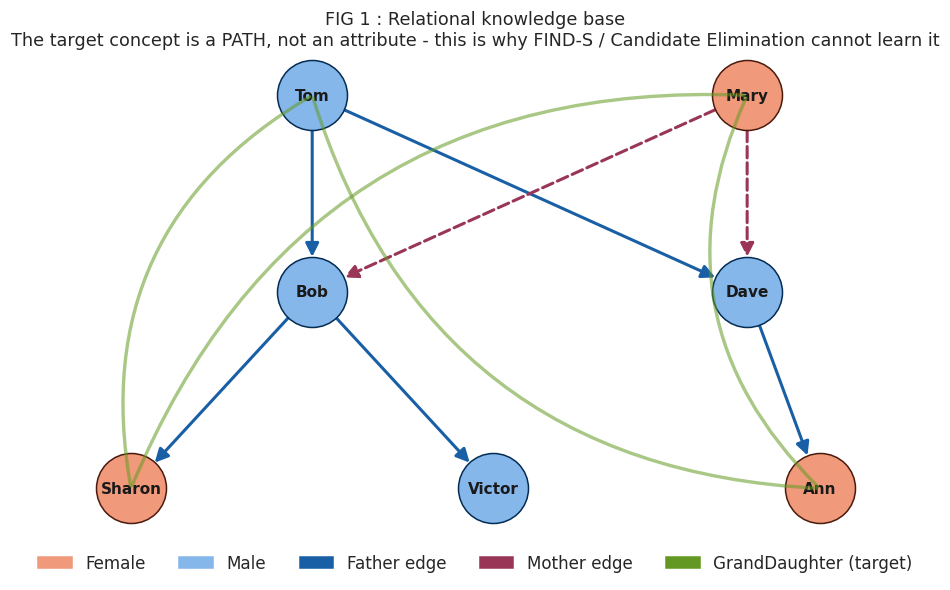

In [11]:
# ============================================================================
# SECTION 6 : VISUAL ANALYSIS
# ============================================================================
#
# FIGURE 1
# The knowledge base as a graph : this is WHY we need first order logic.
# The concept lives in the EDGES, not in any single node's attributes.
# ============================================================================

G = nx.DiGraph()

G.add_nodes_from(CONSTANTS)

for a, b in FACTS["Father"]:
    G.add_edge(
        a,
        b,
        rel="Father"
    )

for a, b in FACTS["Mother"]:
    G.add_edge(
        a,
        b,
        rel="Mother"
    )


pos_layout = {
    "Tom": (-1.2, 2),
    "Mary": (1.2, 2),
    "Bob": (-1.2, 1),
    "Dave": (1.2, 1),
    "Sharon": (-2.2, 0),
    "Victor": (-0.2, 0),
    "Ann": (1.6, 0)
}


fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

female = [
    n
    for n in CONSTANTS
    if is_true("Female", (n,))
]

male = [
    n
    for n in CONSTANTS
    if n not in female
]


nx.draw_networkx_nodes(
    G,
    pos_layout,
    nodelist=female,
    node_color="#F0997B",
    node_size=2100,
    edgecolors="#4A1B0C",
    ax=ax
)

nx.draw_networkx_nodes(
    G,
    pos_layout,
    nodelist=male,
    node_color="#85B7EB",
    node_size=2100,
    edgecolors="#042C53",
    ax=ax
)

nx.draw_networkx_labels(
    G,
    pos_layout,
    font_size=10,
    font_weight="bold",
    ax=ax
)


f_edges = [
    (a, b)
    for a, b, d in G.edges(data=True)
    if d["rel"] == "Father"
]

m_edges = [
    (a, b)
    for a, b, d in G.edges(data=True)
    if d["rel"] == "Mother"
]


nx.draw_networkx_edges(
    G,
    pos_layout,
    edgelist=f_edges,
    edge_color="#185FA5",
    width=2,
    arrowsize=18,
    node_size=2100,
    ax=ax
)

nx.draw_networkx_edges(
    G,
    pos_layout,
    edgelist=m_edges,
    edge_color="#993556",
    width=2,
    style="dashed",
    arrowsize=18,
    node_size=2100,
    ax=ax
)


for (a, b) in POSITIVES:

    ax.annotate(
        "",
        xy=pos_layout[a],
        xytext=pos_layout[b],
        arrowprops=dict(
            arrowstyle="-",
            color="#639922",
            lw=2.2,
            alpha=0.55,
            connectionstyle="arc3,rad=0.35"
        )
    )


ax.legend(
    handles=[
        Patch(
            color="#F0997B",
            label="Female"
        ),
        Patch(
            color="#85B7EB",
            label="Male"
        ),
        Patch(
            color="#185FA5",
            label="Father edge"
        ),
        Patch(
            color="#993556",
            label="Mother edge"
        ),
        Patch(
            color="#639922",
            label="GrandDaughter (target)"
        )
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=5,
    frameon=False
)


ax.set_title(
    "FIG 1 : Relational knowledge base\n"
    "The target concept is a PATH, not an attribute - "
    "this is why FIND-S / Candidate Elimination cannot learn it",
    fontsize=11.5
)

ax.axis("off")

plt.tight_layout()
plt.show()

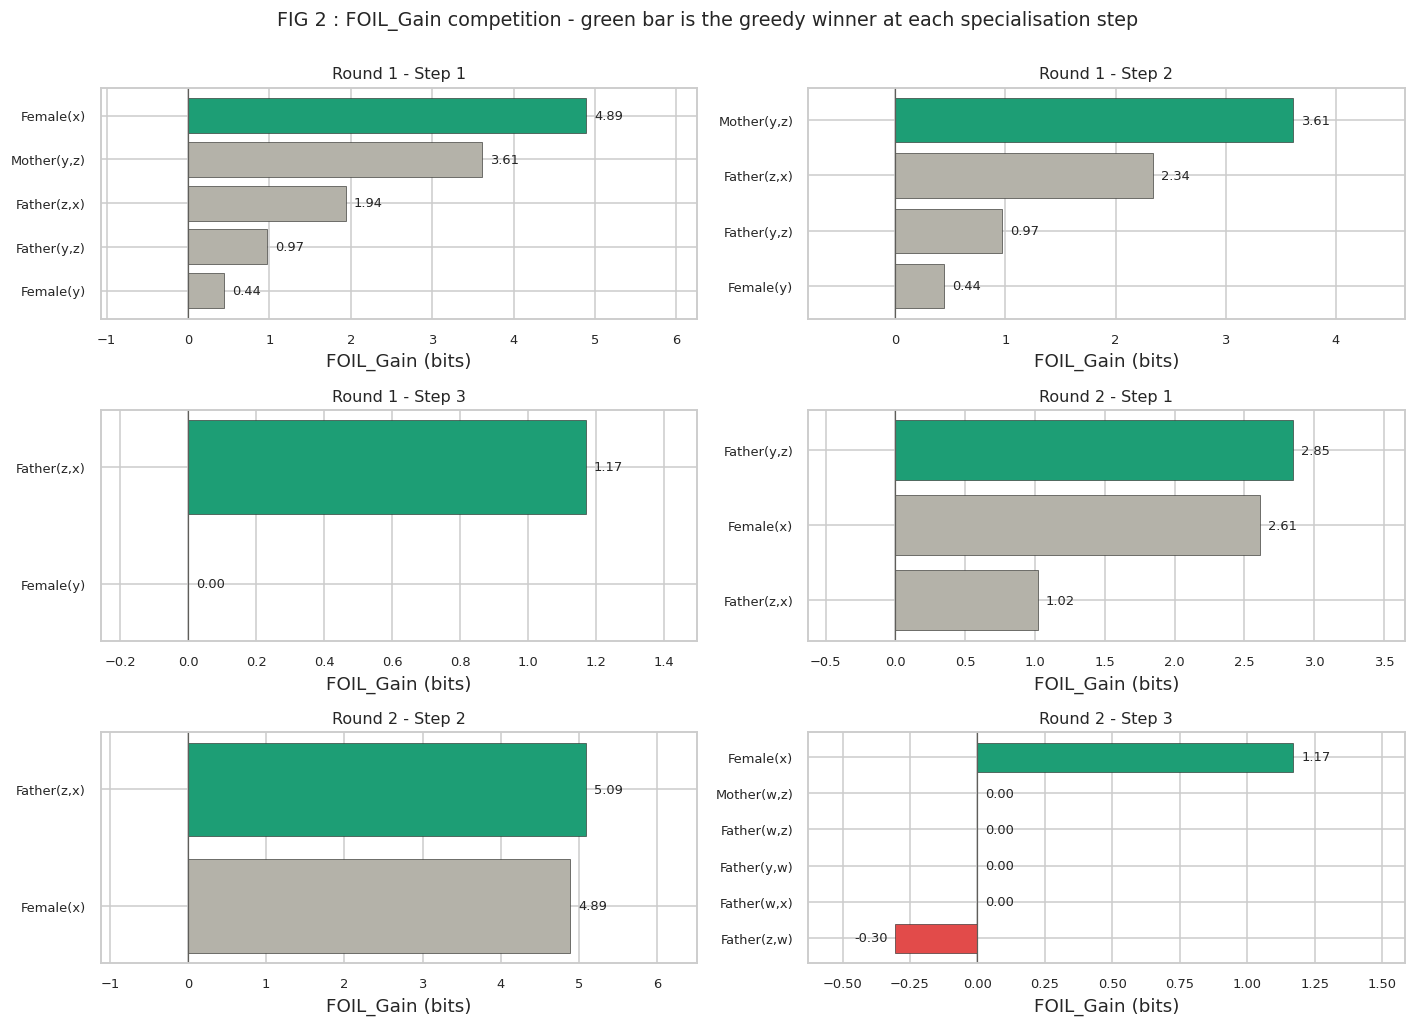

In [12]:
# ---------------------------------------------------------------------------
# FIGURE 2
# FOIL_Gain competition between candidate literals at every step.
# ---------------------------------------------------------------------------

steps = trace_df.groupby(
    ["round", "step"]
).size().index.tolist()

ncol = 2

nrow = int(
    math.ceil(
        len(steps) / ncol
    )
)

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(13, 3.1 * nrow)
)

axes = np.array(axes).reshape(-1)


for ax, (rnd, stp) in zip(
    axes,
    steps
):

    sub = trace_df[
        (trace_df["round"] == rnd)
        &
        (trace_df["step"] == stp)
    ]

    sub = sub.sort_values(
        "gain",
        ascending=True
    ).tail(7)

    hi = sub["gain"].max()
    lo = min(
        0.0,
        sub["gain"].min()
    )

    span = max(
        hi - lo,
        0.5
    )

    colors = [
        "#1D9E75"
        if g == hi
        else (
            "#E24B4A"
            if g < 0
            else "#B4B2A9"
        )
        for g in sub["gain"]
    ]

    ax.barh(
        sub["literal"],
        sub["gain"],
        color=colors,
        edgecolor="#2C2C2A",
        lw=0.4
    )

    for yi, g in enumerate(
        sub["gain"]
    ):

        off = 0.02 * span

        ax.text(
            g + off
            if g >= 0
            else g - off,
            yi,
            "%.2f" % g,
            va="center",
            ha="left"
            if g >= 0
            else "right",
            fontsize=8.5
        )

    ax.axvline(
        0,
        color="#5F5E5A",
        lw=0.8
    )

    ax.set_title(
        "Round %d - Step %d"
        % (rnd, stp),
        fontsize=10.5
    )

    ax.set_xlabel(
        "FOIL_Gain (bits)"
    )

    ax.set_xlim(
        lo - 0.22 * span,
        hi + 0.28 * span
    )

    ax.tick_params(
        labelsize=8.5
    )


for ax in axes[len(steps):]:
    ax.axis("off")


fig.suptitle(
    "FIG 2 : FOIL_Gain competition - "
    "green bar is the greedy winner "
    "at each specialisation step",
    fontsize=12.5,
    y=1.0
)

plt.tight_layout()
plt.show()

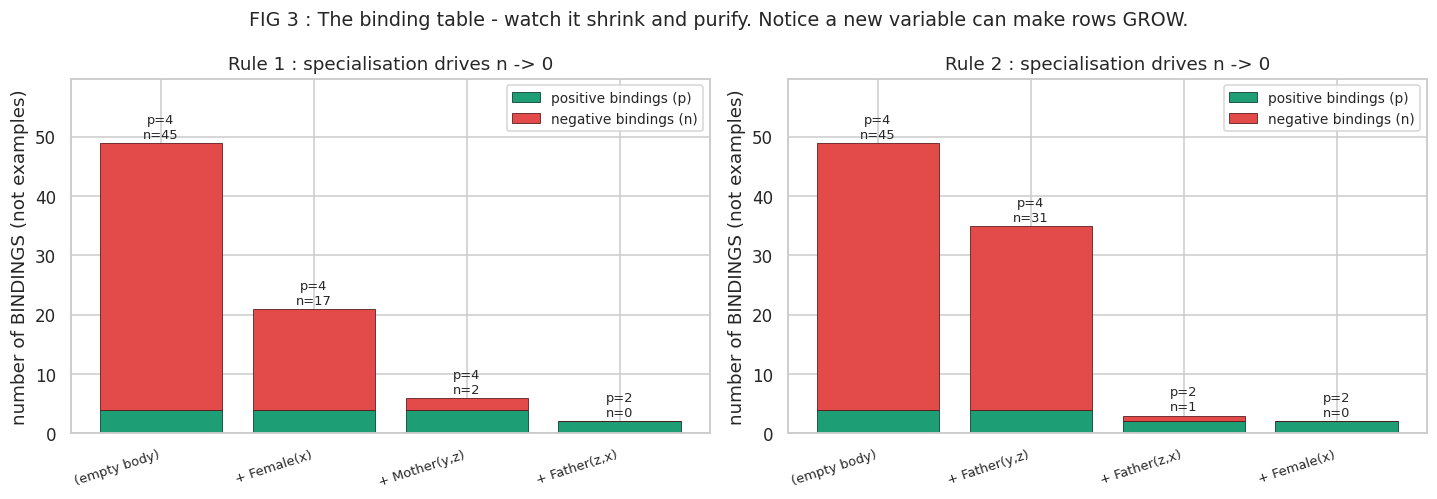

In [13]:
# ---------------------------------------------------------------------------
# FIGURE 3
# How the binding table shrinks and purifies, step by step.
# ---------------------------------------------------------------------------

prog = []

for r_i, body in enumerate(
    RULES,
    1
):

    universe = ALL_PAIRS
    pos_set = set(POSITIVES)

    bindings = [
        {
            "x": a,
            "y": b
        }
        for (a, b) in universe
    ]

    pi, ni = split_bindings(
        bindings,
        pos_set
    )

    prog.append({
        "round": r_i,
        "step": 0,
        "label": "(empty body)",
        "p": len(pi),
        "n": len(ni)
    })

    for s_i, lit in enumerate(
        body,
        1
    ):

        bindings, _ = extend_bindings(
            bindings,
            lit
        )

        pi, ni = split_bindings(
            bindings,
            pos_set
        )

        prog.append({
            "round": r_i,
            "step": s_i,
            "label": lit_str(lit),
            "p": len(pi),
            "n": len(ni)
        })


prog_df = pd.DataFrame(prog)


fig, axes = plt.subplots(
    1,
    len(RULES),
    figsize=(6.6 * len(RULES), 4.6),
    squeeze=False
)


for ax, r_i in zip(
    axes[0],
    sorted(
        prog_df["round"].unique()
    )
):

    sub = prog_df[
        prog_df["round"] == r_i
    ]

    idx = np.arange(
        len(sub)
    )

    ax.bar(
        idx,
        sub["p"],
        color="#1D9E75",
        label="positive bindings (p)",
        edgecolor="#04342C",
        lw=0.5
    )

    ax.bar(
        idx,
        sub["n"],
        bottom=sub["p"],
        color="#E24B4A",
        label="negative bindings (n)",
        edgecolor="#501313",
        lw=0.5
    )

    for i, (p, n) in enumerate(
        zip(
            sub["p"],
            sub["n"]
        )
    ):

        ax.text(
            i,
            p + n + 0.8,
            "p=%d\nn=%d" % (p, n),
            ha="center",
            fontsize=8.5
        )

    ax.set_xticks(idx)

    ax.set_xticklabels(
        [
            "+ " + l
            if s > 0
            else l
            for l, s in zip(
                sub["label"],
                sub["step"]
            )
        ],
        rotation=18,
        ha="right",
        fontsize=8.5
    )

    ax.set_ylabel(
        "number of BINDINGS (not examples)"
    )

    ax.set_title(
        "Rule %d : specialisation drives n -> 0"
        % r_i
    )

    ax.legend(
        fontsize=9
    )

    ax.set_ylim(
        0,
        (sub["p"] + sub["n"]).max() * 1.22
    )


fig.suptitle(
    "FIG 3 : The binding table - "
    "watch it shrink and purify. "
    "Notice a new variable can make rows GROW.",
    fontsize=12.5
)

plt.tight_layout()
plt.show()

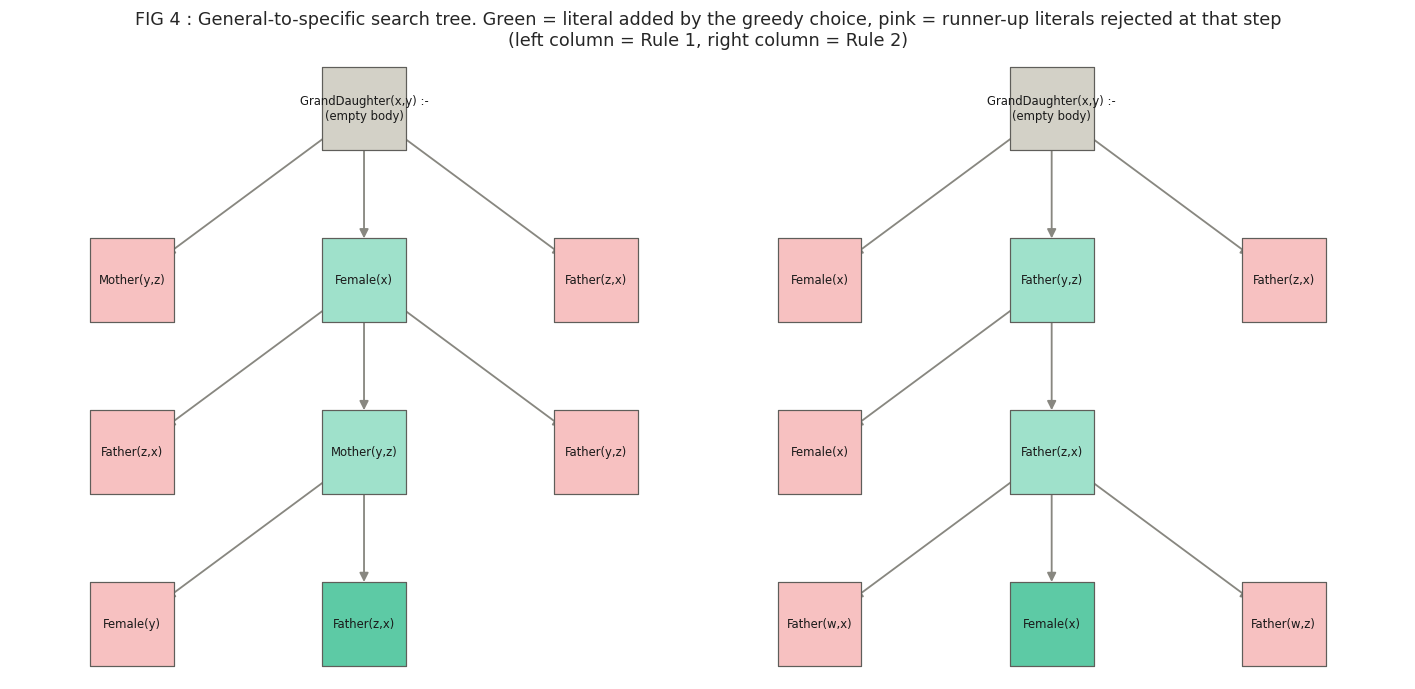

In [14]:
# ---------------------------------------------------------------------------
# FIGURE 4
# The general-to-specific search tree actually explored.
# ---------------------------------------------------------------------------

T = nx.DiGraph()

labels = {}
colors = {}
tpos = {}

y_gap = 1.0


for r_i, body in enumerate(
    RULES,
    1
):

    x_base = (
        r_i - 1
    ) * 4.0

    root = "R%d_s0" % r_i

    T.add_node(root)

    labels[root] = (
        "%s(x,y) :-\n(empty body)"
        % TARGET
    )

    colors[root] = "#D3D1C7"

    tpos[root] = (
        x_base,
        0
    )

    prev = root

    for s_i, lit in enumerate(
        body,
        1
    ):

        # The losing siblings actually considered at this step.
        sibs = trace_df[
            (trace_df["round"] == r_i)
            &
            (trace_df["step"] == s_i)
        ]

        sibs = sibs.sort_values(
            "gain",
            ascending=False
        ).head(3)

        losers = [
            s
            for s in sibs["literal"]
            if s != lit_str(lit)
        ][:2]

        for j, lname in enumerate(
            losers
        ):

            nid = (
                "R%d_s%d_x%d"
                % (
                    r_i,
                    s_i,
                    j
                )
            )

            T.add_node(nid)

            T.add_edge(
                prev,
                nid
            )

            labels[nid] = lname

            colors[nid] = "#F7C1C1"

            tpos[nid] = (
                x_base - 1.35 + j * 2.7,
                -s_i * y_gap
            )

        nid = (
            "R%d_s%d"
            % (
                r_i,
                s_i
            )
        )

        T.add_node(nid)

        T.add_edge(
            prev,
            nid
        )

        labels[nid] = lit_str(lit)

        colors[nid] = "#9FE1CB"

        tpos[nid] = (
            x_base,
            -s_i * y_gap
        )

        prev = nid

    colors[prev] = "#5DCAA5"


fig, ax = plt.subplots(
    figsize=(13, 6.4)
)

nx.draw_networkx_edges(
    T,
    tpos,
    edge_color="#888780",
    width=1.2,
    arrows=True,
    arrowsize=12,
    node_size=3000,
    ax=ax
)

nx.draw_networkx_nodes(
    T,
    tpos,
    node_color=[
        colors[n]
        for n in T.nodes()
    ],
    node_size=3000,
    node_shape="s",
    edgecolors="#5F5E5A",
    linewidths=0.8,
    ax=ax
)

nx.draw_networkx_labels(
    T,
    tpos,
    labels=labels,
    font_size=7.6,
    ax=ax
)

ax.set_title(
    "FIG 4 : General-to-specific search tree. "
    "Green = literal added by the greedy choice, "
    "pink = runner-up literals rejected at that step\n"
    "(left column = Rule 1, right column = Rule 2)",
    fontsize=11.5
)

ax.axis("off")

plt.tight_layout()
plt.show()

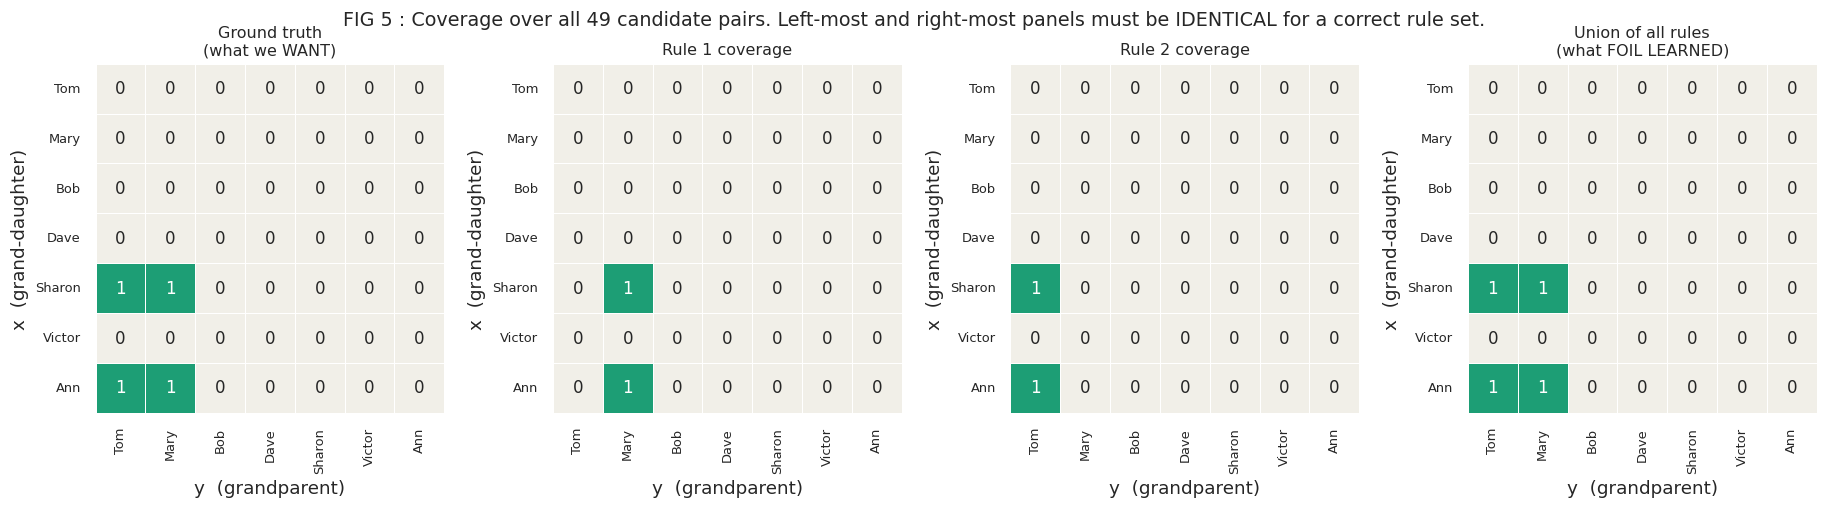

In [15]:
# ---------------------------------------------------------------------------
# FIGURE 5
# Coverage heatmaps over the full 7 x 7 hypothesis space.
# ---------------------------------------------------------------------------

n_c = len(CONSTANTS)

truth = np.array([
    [
        1 if ground_truth(a, b) else 0
        for b in CONSTANTS
    ]
    for a in CONSTANTS
])


cov_maps = [truth]

titles = [
    "Ground truth\n(what we WANT)"
]


union = np.zeros_like(truth)


for i, body in enumerate(
    RULES,
    1
):

    cov = evaluate_rule(
        body,
        ALL_PAIRS
    )

    m = np.array([
        [
            1 if (a, b) in cov else 0
            for b in CONSTANTS
        ]
        for a in CONSTANTS
    ])

    union = np.maximum(
        union,
        m
    )

    cov_maps.append(m)

    titles.append(
        "Rule %d coverage" % i
    )


cov_maps.append(union)

titles.append(
    "Union of all rules\n(what FOIL LEARNED)"
)


fig, axes = plt.subplots(
    1,
    len(cov_maps),
    figsize=(
        4.2 * len(cov_maps),
        4.4
    )
)


for ax, m, t in zip(
    axes,
    cov_maps,
    titles
):

    sns.heatmap(
        m,
        annot=True,
        fmt="d",
        cbar=False,
        square=True,
        cmap=sns.color_palette([
            "#F1EFE8",
            "#1D9E75"
        ]),
        linewidths=0.6,
        linecolor="white",
        xticklabels=CONSTANTS,
        yticklabels=CONSTANTS,
        ax=ax
    )

    ax.set_title(
        t,
        fontsize=10.5
    )

    ax.set_xlabel(
        "y  (grandparent)"
    )

    ax.set_ylabel(
        "x  (grand-daughter)"
    )

    ax.tick_params(
        labelsize=8.5
    )


fig.suptitle(
    "FIG 5 : Coverage over all %d candidate pairs. "
    "Left-most and right-most panels must be IDENTICAL "
    "for a correct rule set."
    % len(ALL_PAIRS),
    fontsize=12.5
)

plt.tight_layout()
plt.show()

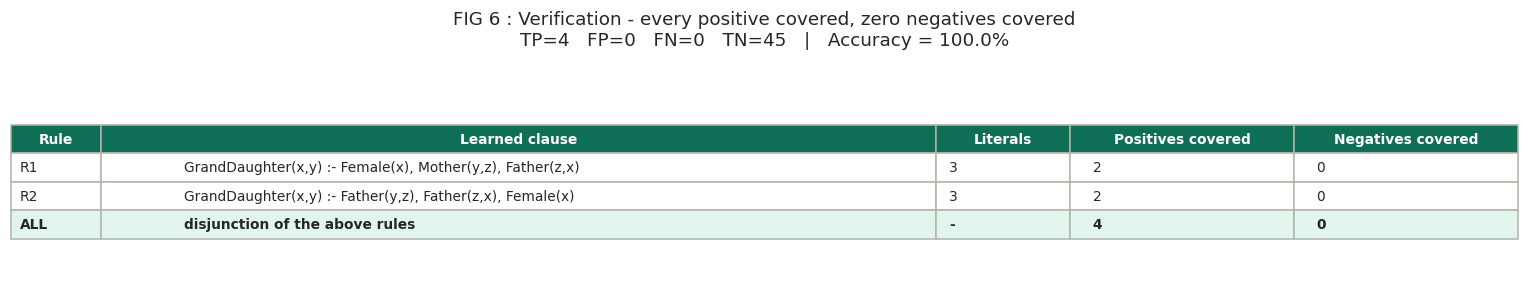

In [16]:
# ---------------------------------------------------------------------------
# FIGURE 6
# Verification summary table.
# ---------------------------------------------------------------------------

predicted = set()

for body in RULES:
    predicted |= evaluate_rule(
        body,
        ALL_PAIRS
    )


TP = len([
    p
    for p in ALL_PAIRS
    if p in predicted
    and ground_truth(*p)
])

FP = len([
    p
    for p in ALL_PAIRS
    if p in predicted
    and not ground_truth(*p)
])

FN = len([
    p
    for p in ALL_PAIRS
    if p not in predicted
    and ground_truth(*p)
])

TN = (
    len(ALL_PAIRS)
    - TP
    - FP
    - FN
)


rows = []

for i, body in enumerate(
    RULES,
    1
):

    cov = evaluate_rule(
        body,
        ALL_PAIRS
    )

    rows.append([
        "R%d" % i,
        rule_str(body),
        len(body),
        len(
            cov
            & set(POSITIVES)
        ),
        len(
            cov
            & set(NEGATIVES)
        )
    ])


rows.append([
    "ALL",
    "disjunction of the above rules",
    "-",
    TP,
    FP
])


fig, ax = plt.subplots(
    figsize=(
        14,
        1.05 + 0.62 * len(rows)
    )
)

ax.axis("off")


tbl = ax.table(
    cellText=rows,
    colLabels=[
        "Rule",
        "Learned clause",
        "Literals",
        "Positives covered",
        "Negatives covered"
    ],
    cellLoc="left",
    loc="center",
    colWidths=[
        0.06,
        0.56,
        0.09,
        0.15,
        0.15
    ]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.7)


for (r, c), cell in tbl.get_celld().items():

    cell.set_edgecolor(
        "#B4B2A9"
    )

    if r == 0:

        cell.set_facecolor(
            "#0F6E56"
        )

        cell.set_text_props(
            color="white",
            weight="bold"
        )

    elif r == len(rows):

        cell.set_facecolor(
            "#E1F5EE"
        )

        cell.set_text_props(
            weight="bold"
        )


ax.set_title(
    "FIG 6 : Verification - "
    "every positive covered, zero negatives covered\n"
    "TP=%d   FP=%d   FN=%d   TN=%d   |   Accuracy = %.1f%%"
    % (
        TP,
        FP,
        FN,
        TN,
        100.0 * (TP + TN) / len(ALL_PAIRS)
    ),
    fontsize=12,
    pad=16
)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================================
# SECTION 7 : PRINTED SUMMARY FOR THE BOARD
# ============================================================================

print("\n" + "=" * 78)
print(
    " ROUND-BY-ROUND SUMMARY ".center(
        78,
        "="
    )
)
print("=" * 78)


print(
    tabulate(
        pd.DataFrame(ROUND_LOG),
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)


print(
    "\nCONFUSION MATRIX over all %d pairs"
    % len(ALL_PAIRS)
)


print(
    tabulate(
        [
            [
                "Actual POSITIVE",
                TP,
                FN
            ],
            [
                "Actual NEGATIVE",
                FP,
                TN
            ]
        ],
        headers=[
            "",
            "Predicted POS",
            "Predicted NEG"
        ],
        tablefmt="grid"
    )
)


print("\nTALKING POINTS")

print(
    " 1. Female(x) is an ATTRIBUTE test - "
    "propositional learners can do this."
)

print(
    " 2. Father(y,z) introduces variable z that is NOT in the head."
)

print(
    "    That single line is the reason FOIL exists."
)

print(
    " 3. p and n are counted over BINDINGS. "
    "One example can produce many rows."
)

print(
    " 4. t in FOIL_Gain is the survival weight: "
    "bits saved x positives kept."
)

print(
    " 5. FOIL is GREEDY - compare the literal ORDER "
    "chosen in Rule 1 vs Rule 2."
)

print(
    " 6. Two rules were needed because the concept is a DISJUNCTION"
)

print(
    "    (grandparent through a mother OR through a father)."
)

print("=" * 78)


=========================== ROUND-BY-ROUND SUMMARY ===========================
+---------+-----------------------------------------------------------+------------+-----------+--------------------+-----------+-----------+
|   round | rule                                                      |   literals |   covered |   remaining_before |   final_p |   final_n |
+=========+===========================================================+============+===========+====================+===========+===========+
|       1 | GrandDaughter(x,y) :- Female(x), Mother(y,z), Father(z,x) |          3 |         2 |                  4 |         2 |         0 |
+---------+-----------------------------------------------------------+------------+-----------+--------------------+-----------+-----------+
|       2 | GrandDaughter(x,y) :- Father(y,z), Father(z,x), Female(x) |          3 |         2 |                  2 |         2 |         0 |
+---------+---------------------------------------------------------